# **<center>07_eval_external_generalization</center>**

### Table of Contents

1. **Notebook Overview**  
   - Objective: impact of training data volume on DL performance  
   - Incremental training strategy (25%, 50%, 75% and 100% of the dataset)  
   - Clinical and methodological motivation  

2. **Environment Setup**  
   - Import of required libraries and utility functions  
   - Basic configuration for plotting and reproducibility  

3. **Loading Images, Labels and Metadata**  
   - 3.1. Load test images  
   - 3.2. Load metadata  
   - Label extraction and consistency checks  

4. **Load Trained Models**  
   - Best CNN models trained with 25%, 50%, 75% and 100% of the training data  
   - Model architecture consistency across experiments  

5. **Models Evaluation: Incremental training-set sizes (25/50/75/100%)**  
   - 5.1. Evaluation of each model on the test set  
       - Probabilistic inference and optimal threshold selection (Youden index)  
       - Confusion matrices and global performance metrics  
         (sensitivity, specificity, PPV, NPV, F1-score, accuracy)  
       - ROC curve analysis and AUC with analytical confidence intervals  
       - Saving of quantitative results and ROC figures to disk
   - 5.2. Statistical Comparison Between Models  
     - Paired comparison of ROC AUC using the DeLong test  
     - Paired comparison of classification errors using McNemar’s test  

7. **Models Explainability**  
   - Grad-CAM-based visual explanation of CNN predictions  
   - Heatmap generation for each incremental model  
   - Qualitative comparison across training-set sizes  

8. **Summary and Conclusions**  
   - Impact of training data volume on performance and robustness  
   - Quantitative and qualitative synthesis of results  
   - Implications for dataset design in clinical DL applications  


### **1. Notebook Overview**

The impact of training dataset size on the external generalization of deep learning (DL) models for detecting rotator cuff calcific tendinopathy in shoulder radiographs is investigated. Starting from a unified CNN architecture and training configuration, four models are trained using incremental proportions of the institutional training data (25%, 50%, 75%, and 100%). The objective is to quantify how increasing data volume affects the model's ability to maintain diagnostic accuracy and robustness when deployed in a novel clinical environment.

All models are trained using subsets from the same primary institution, ensuring consistent acquisition protocols and labeling. By progressively increasing the number of training images while keeping the external test set fixed, this experiment isolates the effect of data volume on the model's capacity to learn generalizable pathological features versus site-specific technical noise. This setup allows for a direct comparison of performance trajectories across different training regimes.

Understanding the scaling laws of external performance is critical in medical imaging, where large-scale data accumulation often encounters diminishing returns. This notebook aims to identify the saturation point—the critical data mass beyond which additional training samples no longer improve external reliability. These results offer practical insights into "institutional over-optimization" and help define efficient data requirements for developing clinically translatable DL systems.

### **2. Environment Setup: Import required libraries**

In [1]:
# TensorFlow & Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import load_model

# NumPy & Pandas
import numpy as np
import pandas as pd

# Scikit-learn
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

# Visualization
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from IPython.display import Image, display
import math

# System utilities & processing
import os
import cv2
from tqdm import tqdm
from datetime import datetime
from scipy import stats
import seaborn as sns

from scipy.stats import norm

2026-04-07 10:55:54.921286: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-07 10:55:55.744142: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


### **3. Load images and metadata**

#### **3.1. Load images**

In [2]:
# Base directory containing the subsets (UNet-cropped version)
subsets_path = "Dataset/External_text_Institution_2/Subsets_unet"

# Retrieve the list of all subset folders
subset_folders = [
    folder for folder in os.listdir(subsets_path)
    if os.path.isdir(os.path.join(subsets_path, folder)) and folder != ".ipynb_checkpoints"
]

# Dictionary to store image paths per subset
external_subsets = {}

for folder in subset_folders:
    folder_path = os.path.join(subsets_path, folder)

    image_paths = [
        os.path.join(folder_path, fname)
        for fname in os.listdir(folder_path)
        if fname.endswith(".npy")
    ]

    external_subsets[folder] = image_paths
    print(f"Images in {folder}: {len(image_paths)}")

# Display total number of subsets
print(f"\nTotal subsets: {len(external_subsets)}")


Images in TC_CZC2391BGR_villalba_test: 126
Images in TC_PRIMO_villalba_test: 66
Images in TC_CZC2161RCP_villalba_test: 116

Total subsets: 3


In [3]:
# Load images

def load_images(images_path):
    X_list = []
    shapes_detected = set()

    for image_path in tqdm(images_path, desc='📥 Cargando imágenes'):
               
        if ".ipynb_checkpoints" in image_path:
            continue
        if not image_path.endswith(".npy"):
            continue
            
        try:
            X_ = np.load(image_path)
            shapes_detected.add(X_.shape)
            X_list.append(X_)
        except Exception as e:
            print(f' Error al cargar {image_path}: {e}')

    if len(shapes_detected) > 1:
        print(f' Se detectaron múltiples shapes: {shapes_detected}')
    else:
        print(f' Todas las imágenes tienen shape: {list(shapes_detected)[0]}')

    try:
        X = np.stack(X_list)  # más seguro que np.array en este contexto
    except Exception as e:
        print(f' Error al convertir lista a array: {e}')
        X = X_list  # fallback: devuelve la lista sin convertir a array

    return X


In [4]:
# === Load external test images ===
X_external_dict = {}

for subset_name, image_paths in external_subsets.items():
    print(f"\nLoading images from external subset: {subset_name}")

    X_external_dict[subset_name] = load_images(image_paths)

    print(
        f"Loaded {X_external_dict[subset_name].shape[0]} images "
        f"from subset {subset_name}"
    )

# === Concatenate all external images into a single array ===
X_all = np.concatenate(list(X_external_dict.values()), axis=0)

print(f"\nAll external images concatenated. Final shape: {X_all.shape}")



Loading images from external subset: TC_CZC2391BGR_villalba_test


📥 Cargando imágenes: 100%|██████████| 126/126 [00:00<00:00, 703.28it/s]

 Todas las imágenes tienen shape: (300, 300, 3)


Loaded 126 images from subset TC_CZC2391BGR_villalba_test

Loading images from external subset: TC_PRIMO_villalba_test


📥 Cargando imágenes: 100%|██████████| 66/66 [00:00<00:00, 1127.54it/s]


 Todas las imágenes tienen shape: (300, 300, 3)
Loaded 66 images from subset TC_PRIMO_villalba_test

Loading images from external subset: TC_CZC2161RCP_villalba_test


📥 Cargando imágenes: 100%|██████████| 116/116 [00:00<00:00, 970.38it/s] 


 Todas las imágenes tienen shape: (300, 300, 3)
Loaded 116 images from subset TC_CZC2161RCP_villalba_test

All external images concatenated. Final shape: (308, 300, 300, 3)


#### **3.2. Load metadata**

In [5]:
# === Load metadata DataFrames for external subsets ===
df_external_dict = {}

# Load the CSV file associated with each subset
for subset_name in external_subsets.keys():
    csv_path = os.path.join(subsets_path, f"{subset_name}.csv")

    df = pd.read_csv(csv_path)
    df_external_dict[subset_name] = df

    print(f"Rows in {subset_name}: {df.shape[0]}")

# === Concatenate all metadata DataFrames into a single DataFrame ===
df_all = pd.concat(df_external_dict.values(), axis=0).reset_index(drop=True)

print(f"Combined DataFrame shape: {df_all.shape}")


Rows in TC_CZC2391BGR_villalba_test: 126
Rows in TC_PRIMO_villalba_test: 66
Rows in TC_CZC2161RCP_villalba_test: 116
Combined DataFrame shape: (308, 16)


In [6]:
# Extract labels for a list of image paths based on metadata stored in a DataFrame

def extract_labels(df, images_path):
    # Crear diccionario: rx_cod → label
    label_dict = dict(zip(df['rx_cod'], df['label_CalTend']))
    
    # Extraer etiquetas basadas en el nombre del archivo (sin extensión)
    y = np.array([
        label_dict[os.path.splitext(os.path.basename(path))[0]]
        for path in images_path
    ])
    
    return y
    

In [7]:
# Extract labels for external subsets
y_external_dict = {}

for subset_name in external_subsets.keys():
    print(f"\nExtracting labels for subset: {subset_name}")

    image_paths = external_subsets[subset_name]
    df = pd.read_csv(os.path.join(subsets_path, f"{subset_name}.csv"))

    y = extract_labels(df, image_paths)
    y_external_dict[subset_name] = y

    print(f"Extracted labels: {len(y)}")



Extracting labels for subset: TC_CZC2391BGR_villalba_test
Extracted labels: 126

Extracting labels for subset: TC_PRIMO_villalba_test
Extracted labels: 66

Extracting labels for subset: TC_CZC2161RCP_villalba_test
Extracted labels: 116


In [8]:
# Concatenate external image arrays
X_all = np.concatenate(
    [X_external_dict[name] for name in external_subsets.keys()],
    axis=0
)
print(f"Total number of images: {X_all.shape}")


# === Concatenate external label arrays ===
y_all = np.concatenate(
    [y_external_dict[name] for name in external_subsets.keys()],
    axis=0
)
print(f"Total number of labels: {y_all.shape}")


# Concatenate external metadata DataFrames
df_all = (
    pd.concat(
        [df_external_dict[name] for name in external_subsets.keys()],
        axis=0
    )
    .reset_index(drop=True)
)
print(f"Total number of rows in df_all: {df_all.shape}")


# Final consistency check
assert (
    X_all.shape[0] == y_all.shape[0] == df_all.shape[0]
), "Mismatch between images, labels, and metadata"


Total number of images: (308, 300, 300, 3)
Total number of labels: (308,)
Total number of rows in df_all: (308, 16)


### **4. Load Models**

In [9]:
# === Paths to the best CNN models obtained in Experiment 4 ===
model_path_25   = 'big_volume/Tesis_definitivo/Models/all_models/model_25.h5'
model_path_50   = 'big_volume/Tesis_definitivo/Models/all_models/model_50.h5'
model_path_75   = 'big_volume/Tesis_definitivo/Models/all_models/model_75.h5'
model_path_100  = 'big_volume/Tesis_definitivo/Models/all_models/model_100.h5'


# === Load trained models ===

model_25  = load_model(model_path_25)
model_50  = load_model(model_path_50)
model_75  = load_model(model_path_75)
model_100 = load_model(model_path_100)

# === Display model summaries ===

model_25.summary()
model_50.summary()
model_75.summary()
model_100.summary()

2026-04-07 10:55:58.393729: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-07 10:55:58.443677: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-07 10:55:58.446942: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg19 (Functional)          (None, 9, 9, 512)         20024384  
                                                                 
 global_max_pooling2d (Glob  (None, 512)               0         
 alMaxPooling2D)                                                 
                                                                 
 dense (Dense)               (None, 1)                 513       
                                                                 
Total params: 20024897 (76.39 MB)
Trainable params: 20024897 (76.39 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg19 (Functional)          (None, 9, 9, 512)         20024

### **5. Models Evaluation: Incremental training-set sizes (25/50/75/100%)**

#### **5.1. Models evaluation on the test subset**


=== Evaluation: model_25 ===


2026-04-07 10:56:01.782652: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 332640000 exceeds 10% of free system memory.
2026-04-07 10:56:02.122977: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 332640000 exceeds 10% of free system memory.
2026-04-07 10:56:02.673631: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8600


10/10 [==============================] - 14s 729ms/step
Confusion matrix:
[[113 41]
 [50 104]]

cut_off_threshold_point: 0.8245999813079834
Sensitivity: 0.6753
Specificity: 0.7338
PPV: 0.7172
NPV: 0.6933
F1 score: 0.6957
Accuracy: 0.7045
ROC AUC: 0.7688
CI 90%: [0.7246 – 0.8129]
CI 95%: [0.7161 – 0.8214]
CI 99%: [0.6996 – 0.8379]

=== Evaluation: model_50 ===


2026-04-07 10:56:16.771928: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 332640000 exceeds 10% of free system memory.
2026-04-07 10:56:17.060663: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 332640000 exceeds 10% of free system memory.


10/10 [==============================] - 2s 256ms/step
Confusion matrix:
[[141 13]
 [49 105]]

cut_off_threshold_point: 0.8712000250816345
Sensitivity: 0.6818
Specificity: 0.9156
PPV: 0.8898
NPV: 0.7421
F1 score: 0.7721
Accuracy: 0.7987
ROC AUC: 0.874
CI 90%: [0.8405 – 0.9075]
CI 95%: [0.8341 – 0.914]
CI 99%: [0.8215 – 0.9265]

=== Evaluation: model_75 ===


2026-04-07 10:56:20.647634: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 332640000 exceeds 10% of free system memory.


10/10 [==============================] - 3s 257ms/step
Confusion matrix:
[[149 5]
 [32 122]]

cut_off_threshold_point: 0.6635000109672546
Sensitivity: 0.7922
Specificity: 0.9675
PPV: 0.9606
NPV: 0.8232
F1 score: 0.8683
Accuracy: 0.8799
ROC AUC: 0.9229
CI 90%: [0.8966 – 0.9492]
CI 95%: [0.8916 – 0.9543]
CI 99%: [0.8817 – 0.9641]

=== Evaluation: model_100 ===
10/10 [==============================] - 3s 258ms/step
Confusion matrix:
[[151 3]
 [34 120]]

cut_off_threshold_point: 0.715399980545044
Sensitivity: 0.7792
Specificity: 0.9805
PPV: 0.9756
NPV: 0.8162
F1 score: 0.8664
Accuracy: 0.8799
ROC AUC: 0.9166
CI 90%: [0.8892 – 0.944]
CI 95%: [0.884 – 0.9492]
CI 99%: [0.8737 – 0.9595]


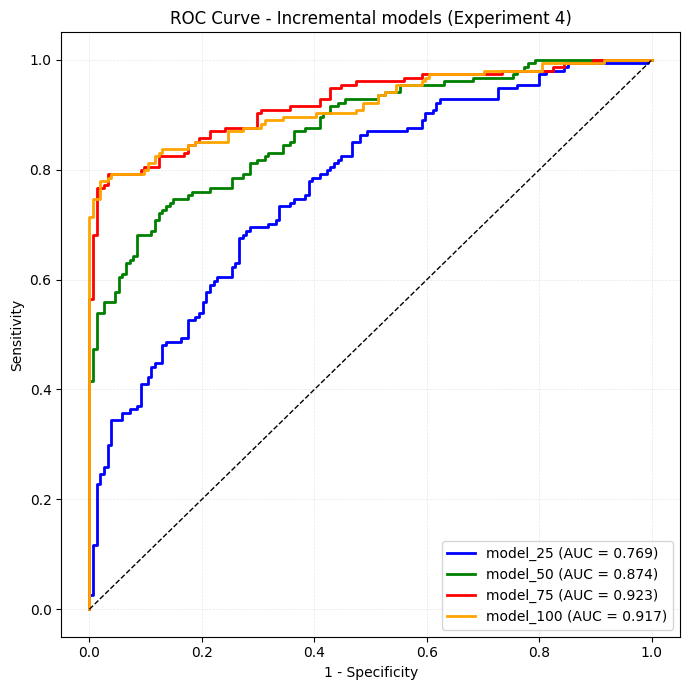

,Evaluation_name,cut_off_threshold_point,tn,fp,fn,tp,sensitivity,specificity,PPV,NPV,F1_score,accuracy,ROC_AUC,CI_90_lower,CI_90_upper,CI_95_lower,CI_95_upper,CI_99_lower,CI_99_upper
0,model_25,0.8246,113,41,50,104,0.6753,0.7338,0.7172,0.6933,0.6957,0.7045,0.7688,0.7246,0.8129,0.7161,0.8214,0.6996,0.8379
1,model_50,0.8712,141,13,49,105,0.6818,0.9156,0.8898,0.7421,0.7721,0.7987,0.8740,0.8405,0.9075,0.8341,0.9140,0.8215,0.9265
2,model_75,0.6635,149,5,32,122,0.7922,0.9675,0.9606,0.8232,0.8683,0.8799,0.9229,0.8966,0.9492,0.8916,0.9543,0.8817,0.9641
3,model_100,0.7154,151,3,34,120,0.7792,0.9805,0.9756,0.8162,0.8664,0.8799,0.9166,0.8892,0.9440,0.8840,0.9492,0.8737,0.9595


In [10]:
# Base path to save evaluation outputs for Experiment 4
base_save_path = 'big_volume/Tesis_definitivo/Evaluation/Paper_ER_EG'
os.makedirs(base_save_path, exist_ok=True)

# Models must be loaded beforehand (model_25, model_50, model_75, model_100)
models_dict = {
    "model_25": model_25,
    "model_50": model_50,
    "model_75": model_75,
    "model_100": model_100
}

# Keep the same colors as in the original code
model_colors = {
    "model_25": "blue",
    "model_50": "green",
    "model_75": "red",
    "model_100": "orange"
}


def auc_confidence_interval(y_true, y_score):
    """
    Compute the AUC and its confidence intervals using the method of
    Hanley & McNeil for binormal ROC curves.

    Parameters
    ----------
    y_true : array-like
        Binary ground-truth labels (0/1).
    y_score : array-like
        Predicted probabilities or continuous scores.

    Returns
    -------
    auc : float
        Area under the ROC curve.
    ci : dict
        Dictionary with lower and upper bounds for 90%, 95% and 99% CIs.
    """
    auc = roc_auc_score(y_true, y_score)
    n1 = sum(y_true)
    n2 = len(y_true) - n1
    q1 = auc / (2 - auc)
    q2 = 2 * auc**2 / (1 + auc)
    se_auc = np.sqrt(
        (auc * (1 - auc) +
         (n1 - 1) * (q1 - auc**2) +
         (n2 - 1) * (q2 - auc**2)) / (n1 * n2)
    )

    z = {0.90: 1.6449, 0.95: 1.96, 0.99: 2.5758}
    ci = {}
    for level in z:
        delta = z[level] * se_auc
        ci[f'CI {int(level * 100)}% lower'] = max(0, auc - delta)
        ci[f'CI {int(level * 100)}% upper'] = min(1, auc + delta)
    return auc, ci


# Store ROC curves for later joint plotting
roc_curves = {}

# Collect metrics for summary table
metrics_summary = []

# === Evaluation for each model ===
for name, model in models_dict.items():
    print(f'\n=== Evaluation: {name} ===')

    # Directory for saving results (kept consistent with other experiments)
    save_dir = os.path.join(base_save_path, name)
    os.makedirs(save_dir, exist_ok=True)

    # Predictions (probabilities)
    y_prob = model.predict(X_all).ravel()

    # ROC curve and Youden threshold
    fpr, tpr, thresholds = roc_curve(y_all, y_prob)
    youden_index = np.argmax(tpr - fpr)
    best_threshold = thresholds[youden_index]

    # Binary predictions using the chosen threshold
    y_pred = (y_prob >= best_threshold).astype(int)

    # Confusion matrix and metrics
    tn, fp, fn, tp = confusion_matrix(y_all, y_pred).ravel()
    sensitivity = recall_score(y_all, y_pred)
    specificity = tn / (tn + fp) if (tn + fp) else 0
    ppv = precision_score(y_all, y_pred, zero_division=0)
    npv = tn / (tn + fn) if (tn + fn) else 0
    f1 = f1_score(y_all, y_pred, zero_division=0)
    acc = accuracy_score(y_all, y_pred)
    auc, ci_dict = auc_confidence_interval(y_all, y_prob)

    print(f'Confusion matrix:\n[[{tn} {fp}]\n [{fn} {tp}]]\n')
    print(f'cut_off_threshold_point: {round(best_threshold, 4)}')
    print(f'Sensitivity: {round(sensitivity, 4)}')
    print(f'Specificity: {round(specificity, 4)}')
    print(f'PPV: {round(ppv, 4)}')
    print(f'NPV: {round(npv, 4)}')
    print(f'F1 score: {round(f1, 4)}')
    print(f'Accuracy: {round(acc, 4)}')
    print(f'ROC AUC: {round(auc, 4)}')
    print(f"CI 90%: [{round(ci_dict['CI 90% lower'], 4)} – {round(ci_dict['CI 90% upper'], 4)}]")
    print(f"CI 95%: [{round(ci_dict['CI 95% lower'], 4)} – {round(ci_dict['CI 95% upper'], 4)}]")
    print(f"CI 99%: [{round(ci_dict['CI 99% lower'], 4)} – {round(ci_dict['CI 99% upper'], 4)}]")

    # Store ROC curve for later joint plot
    roc_curves[name] = (fpr, tpr, auc)

    # ROC curve (per-model)
    plt.figure()
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', color=model_colors[name])
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('1 - Specificity')
    plt.ylabel('Sensitivity')
    plt.title(f'ROC Curve - {name}')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, f'ROC_{name}.png'),
                bbox_inches='tight', dpi=300)
    plt.close()

    # Metrics DataFrame (for this model)
    df_metrics = pd.DataFrame({
        'Evaluation_name': [name],
        'cut_off_threshold_point': [round(best_threshold, 4)],
        'tn': [tn],
        'fp': [fp],
        'fn': [fn],
        'tp': [tp],
        'sensitivity': [round(sensitivity, 4)],
        'specificity': [round(specificity, 4)],
        'PPV': [round(ppv, 4)],
        'NPV': [round(npv, 4)],
        'F1 score': [round(f1, 4)],
        'accuracy': [round(acc, 4)],
        'ROC AUC': [round(auc, 4)],
        'CI 90% lower': [round(ci_dict['CI 90% lower'], 4)],
        'CI 90% upper': [round(ci_dict['CI 90% upper'], 4)],
        'CI 95% lower': [round(ci_dict['CI 95% lower'], 4)],
        'CI 95% upper': [round(ci_dict['CI 95% upper'], 4)],
        'CI 99% lower': [round(ci_dict['CI 99% lower'], 4)],
        'CI 99% upper': [round(ci_dict['CI 99% upper'], 4)],
        'y_true': [list(y_all)],
        'y_pred_prob': [list(y_prob)]
    })
    df_metrics.to_csv(os.path.join(save_dir, f'{name}_metrics.csv'),
                      index=False)

    # Add row to summary list
    metrics_summary.append({
        'Evaluation_name': name,
        'cut_off_threshold_point': round(best_threshold, 4),
        'tn': tn,
        'fp': fp,
        'fn': fn,
        'tp': tp,
        'sensitivity': round(sensitivity, 4),
        'specificity': round(specificity, 4),
        'PPV': round(ppv, 4),
        'NPV': round(npv, 4),
        'F1_score': round(f1, 4),
        'accuracy': round(acc, 4),
        'ROC_AUC': round(auc, 4),
        'CI_90_lower': round(ci_dict['CI 90% lower'], 4),
        'CI_90_upper': round(ci_dict['CI 90% upper'], 4),
        'CI_95_lower': round(ci_dict['CI 95% lower'], 4),
        'CI_95_upper': round(ci_dict['CI 95% upper'], 4),
        'CI_99_lower': round(ci_dict['CI 99% lower'], 4),
        'CI_99_upper': round(ci_dict['CI 99% upper'], 4),
    })


# === Joint ROC for all incremental models ===
plt.figure(figsize=(7, 7))

for name in models_dict.keys():
    fpr, tpr, auc_val = roc_curves[name]
    plt.plot(
        fpr, tpr,
        label=f'{name} (AUC = {auc_val:.3f})',
        color=model_colors[name],
        linewidth=2
    )

plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlabel('1 - Specificity')
plt.ylabel('Sensitivity')
plt.title('ROC Curve - Incremental models (Experiment 4)')
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.3)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
plt.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.savefig(os.path.join(base_save_path, 'ROC_all_models.png'),
            bbox_inches='tight', dpi=300)
plt.show()
plt.close()

# === Final summary table of all evaluations ===
metrics_df_summary = pd.DataFrame(metrics_summary)
metrics_df_summary.to_csv(os.path.join(base_save_path, 'ALL_MODELS_METRICS.csv'),
                          index=False)

metrics_df_summary


#### **5.2. Statistical comparison between models (DeLong for AUC, McNemar for paired errors)**

In [11]:
# Build a joint DataFrame with aligned cases

def build_joint_eval_df_exp4(y_true, pred_dict):
    """
    Build a joint evaluation DataFrame for incremental models (Exp4).

    Parameters
    ----------
    y_true : array-like
        Ground-truth labels.
    pred_dict : dict
        Mapping model_name -> predicted probabilities.

    Returns
    -------
    df_joint : pd.DataFrame
        DataFrame with columns:
        ['label', 'y_pred_prob_<model_name>', ...]
    """
    df_joint = pd.DataFrame({
        "label": np.asarray(y_true).ravel()
    })

    for model_name, y_prob in pred_dict.items():
        df_joint[f"y_pred_prob_{model_name}"] = np.asarray(y_prob).ravel()

    return df_joint


# Build prediction dictionary (ensure same order as y_all)
pred_dict_exp4 = {
    name: model.predict(X_all).ravel()
    for name, model in models_dict.items()
}

df_joint_exp4 = build_joint_eval_df_exp4(
    y_true=y_all,
    pred_dict=pred_dict_exp4
)

print(f"Aligned cases for Experiment 4: {df_joint_exp4.shape[0]}")


10/10 [==============================] - 2s 265ms/step
Aligned cases for Experiment 4: 308


In [12]:
# === DeLong test for paired ROC AUC comparison (Experiment 4) ===


def _compute_midrank(x):
    """Compute midranks for ties."""
    sorted_idx = np.argsort(x)
    sorted_x = x[sorted_idx]
    N = len(x)
    midranks = np.zeros(N, dtype=float)

    i = 0
    while i < N:
        j = i
        while j < N and sorted_x[j] == sorted_x[i]:
            j += 1
        midrank = 0.5 * (i + j - 1) + 1
        midranks[i:j] = midrank
        i = j

    out = np.empty(N, dtype=float)
    out[sorted_idx] = midranks
    return out


def _fast_delong(predictions, labels):
    """
    Fast DeLong implementation for AUC variance (paired).

    IMPORTANT:
    Samples are reordered so that positives come first.
    predictions: array of shape (n_models, n_samples)
    labels: binary labels (0/1)
    """
    labels = labels.astype(int)

    # Reorder so that positives are first, negatives are last
    order = np.argsort(-labels)  # 1s first, then 0s
    labels = labels[order]
    predictions = predictions[:, order]

    m = np.sum(labels == 1)
    n = np.sum(labels == 0)

    preds_pos = predictions[:, :m]
    preds_neg = predictions[:, m:]

    k = predictions.shape[0]
    tx = np.empty((k, m))
    ty = np.empty((k, n))
    tz = np.empty((k, m + n))

    for r in range(k):
        tx[r] = _compute_midrank(preds_pos[r])
        ty[r] = _compute_midrank(preds_neg[r])
        tz[r] = _compute_midrank(predictions[r])

    aucs = (tz[:, :m].sum(axis=1) - m * (m + 1) / 2) / (m * n)

    v01 = (tz[:, :m] - tx) / n
    v10 = 1.0 - (tz[:, m:] - ty) / m

    sx = np.cov(v01)
    sy = np.cov(v10)

    return aucs, sx / m + sy / n


def delong_roc_test(y_true, pred_model_1, pred_model_2):
    """
    Paired DeLong test for ROC AUC comparison.

    Returns
    -------
    dict with keys:
    - auc1, auc2
    - delta_auc
    - z_score
    - p_value
    """
    y_true = np.asarray(y_true)
    preds = np.vstack([np.asarray(pred_model_1), np.asarray(pred_model_2)])

    aucs, cov = _fast_delong(preds, y_true)
    auc1, auc2 = aucs
    delta_auc = auc1 - auc2

    var = cov[0, 0] + cov[1, 1] - 2 * cov[0, 1]
    z = delta_auc / np.sqrt(var)
    p_value = 2 * (1 - norm.cdf(abs(z)))

    return {
        "auc1": auc1,
        "auc2": auc2,
        "delta_auc": delta_auc,
        "z_score": z,
        "p_value": p_value,
    }

def run_pairwise_delong_exp4(df_joint, alpha=0.05):
    y_true = df_joint["label"].values

    model_names = [
        "model_25",
        "model_50",
        "model_75",
        "model_100",
    ]

    print("\n=== DeLong tests (paired AUC) — Experiment 4 ===")

    results = []

    for i in range(len(model_names)):
        for j in range(i + 1, len(model_names)):
            m1, m2 = model_names[i], model_names[j]

            y1 = df_joint[f"y_pred_prob_{m1}"].values
            y2 = df_joint[f"y_pred_prob_{m2}"].values

            res = delong_roc_test(
                y_true=y_true,
                pred_model_1=y1,
                pred_model_2=y2
            )

            print(f"\nComparison: {m1} vs {m2}")
            print(f"AUC {m1}: {res['auc1']:.4f}")
            print(f"AUC {m2}: {res['auc2']:.4f}")
            print(f"Delta AUC ({m1} - {m2}): {res['delta_auc']:.4f}")
            print(f"Z-score: {res['z_score']:.4f}")
            print(f"P-value (two-sided): {res['p_value']:.4e}")

            results.append((m1, m2, res["p_value"], res["delta_auc"]))

    print(
        "\nNote:\n"
        "- Pairwise DeLong tests compare incremental training sizes.\n"
        "- Consider Holm correction if strict family-wise error control is required."
    )

    return results


_ = run_pairwise_delong_exp4(df_joint_exp4)



=== DeLong tests (paired AUC) — Experiment 4 ===

Comparison: model_25 vs model_50
AUC model_25: 0.7688
AUC model_50: 0.8740
Delta AUC (model_25 - model_50): -0.1052
Z-score: -4.5469
P-value (two-sided): 5.4447e-06

Comparison: model_25 vs model_75
AUC model_25: 0.7688
AUC model_75: 0.9229
Delta AUC (model_25 - model_75): -0.1542
Z-score: -5.9407
P-value (two-sided): 2.8384e-09

Comparison: model_25 vs model_100
AUC model_25: 0.7688
AUC model_100: 0.9166
Delta AUC (model_25 - model_100): -0.1478
Z-score: -5.7352
P-value (two-sided): 9.7401e-09

Comparison: model_50 vs model_75
AUC model_50: 0.8740
AUC model_75: 0.9229
Delta AUC (model_50 - model_75): -0.0489
Z-score: -3.0313
P-value (two-sided): 2.4349e-03

Comparison: model_50 vs model_100
AUC model_50: 0.8740
AUC model_100: 0.9166
Delta AUC (model_50 - model_100): -0.0426
Z-score: -2.8934
P-value (two-sided): 3.8114e-03

Comparison: model_75 vs model_100
AUC model_75: 0.9229
AUC model_100: 0.9166
Delta AUC (model_75 - model_100): 0.

In [13]:
# Automatic interpretation of DeLong test results

def interpret_delong_results_exp4(df_joint, alpha=0.05):
    y_true = df_joint["label"].values

    model_names = [
        "model_25",
        "model_50",
        "model_75",
        "model_100",
    ]

    print("\n=== Interpretation of DeLong tests — Experiment 4 ===")

    for i in range(len(model_names)):
        for j in range(i + 1, len(model_names)):
            m1, m2 = model_names[i], model_names[j]

            y1 = df_joint[f"y_pred_prob_{m1}"].values
            y2 = df_joint[f"y_pred_prob_{m2}"].values

            res = delong_roc_test(y_true, y1, y2)

            auc1, auc2 = res["auc1"], res["auc2"]
            delta, p = res["delta_auc"], res["p_value"]

            if p < alpha:
                better = m1 if delta > 0 else m2
                conclusion = (
                    f"{better} shows a statistically significant higher AUC"
                )
            else:
                conclusion = "no statistically significant difference in AUC is observed"

            print(
                f"- {m1} vs {m2}: "
                f"AUCs = {auc1:.3f} vs {auc2:.3f}, "
                f"ΔAUC = {delta:.3f}, p = {p:.3e} → {conclusion}."
            )


interpret_delong_results_exp4(df_joint_exp4)



=== Interpretation of DeLong tests — Experiment 4 ===
- model_25 vs model_50: AUCs = 0.769 vs 0.874, ΔAUC = -0.105, p = 5.445e-06 → model_50 shows a statistically significant higher AUC.
- model_25 vs model_75: AUCs = 0.769 vs 0.923, ΔAUC = -0.154, p = 2.838e-09 → model_75 shows a statistically significant higher AUC.
- model_25 vs model_100: AUCs = 0.769 vs 0.917, ΔAUC = -0.148, p = 9.740e-09 → model_100 shows a statistically significant higher AUC.
- model_50 vs model_75: AUCs = 0.874 vs 0.923, ΔAUC = -0.049, p = 2.435e-03 → model_75 shows a statistically significant higher AUC.
- model_50 vs model_100: AUCs = 0.874 vs 0.917, ΔAUC = -0.043, p = 3.811e-03 → model_100 shows a statistically significant higher AUC.
- model_75 vs model_100: AUCs = 0.923 vs 0.917, ΔAUC = 0.006, p = 4.958e-01 → no statistically significant difference in AUC is observed.


### **6. Models Explainability**

In [14]:
# Explainability: Grad-CAM heatmaps 

def generate_gradcam_heatmaps(
    model,
    X_images,
    last_conv_layer_name: str = "block5_conv4",
    classifier_layer_names: list[str] | None = None,
    model_type: int = 2,
    overlay_alpha: float = 0.4,
    invert_heatmap: bool = True,
):

    if classifier_layer_names is None:
        classifier_layer_names = ["global_max_pooling2d", "dense"]

    heatmap_overlays = []
    preds_all = []

    # --- 1. Build convolutional model (used for feature map extraction) ---
    if model_type == 2:
        base_model = model.get_layer("vgg19")
        conv_output = base_model.get_layer(last_conv_layer_name).output
        conv_model = tf.keras.Model(inputs=base_model.input, outputs=conv_output)
    else:
        conv_output = model.get_layer(last_conv_layer_name).output
        conv_model = tf.keras.Model(inputs=model.input, outputs=conv_output)

    # --- 2. Build classifier model (maps feature maps -> prediction) ---
    classifier_input = tf.keras.Input(shape=conv_model.output.shape[1:])
    x = classifier_input

    if model_type == 2:
        x = model.get_layer("global_max_pooling2d")(x)
        x = model.get_layer("dense")(x)
    else:
        for layer_name in classifier_layer_names:
            x = model.get_layer(layer_name)(x)

    classifier_model = tf.keras.Model(inputs=classifier_input, outputs=x)

    # --- 3. Grad-CAM per image ---
    for img in X_images:
        img_input = np.expand_dims(img, axis=0)
        original_image = (img * 255).astype("uint8")

        with tf.GradientTape() as tape:
            conv_output_vals = conv_model(img_input)
            tape.watch(conv_output_vals)
            preds = classifier_model(conv_output_vals)
            class_channel = preds[:, 0]

        preds_all.append(float(preds.numpy()[0][0]))

        grads = tape.gradient(class_channel, conv_output_vals)
        pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

        conv_output_vals = conv_output_vals.numpy()[0]
        pooled_grads = pooled_grads.numpy()

        conv_output_vals *= pooled_grads  # broadcast over HxW

        heatmap = np.mean(conv_output_vals, axis=-1)
        heatmap = np.maximum(heatmap, 0)
        heatmap = heatmap / (np.max(heatmap) + 1e-10)

        if invert_heatmap:
            heatmap = 1.0 - heatmap

        heatmap = cv2.resize(heatmap, (original_image.shape[1], original_image.shape[0]))
        heatmap_uint8 = np.uint8(255 * heatmap)
        heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)

        overlay = cv2.addWeighted(heatmap_color, overlay_alpha, original_image, 1.0, 0)
        heatmap_overlays.append(overlay)

    return heatmap_overlays, preds_all


In [15]:
# === Generate Grad-CAM heatmaps for all models ===

# Dictionaries to store results
heatmaps_dict = {}
y_pred_dict = {}

# Last convolutional layer and classifier layers
last_conv_layer_name = "block5_conv4"
classifier_layers = ["global_max_pooling2d", "dense"]

# Grad-CAM generation per model
for name, model in models_dict.items():
    print(f"Generating Grad-CAM heatmaps for {name}...")

    heatmaps, preds = generate_gradcam_heatmaps(
        model,
        X_all,
        last_conv_layer_name,
        classifier_layers
    )

    heatmaps_dict[name] = heatmaps
    y_pred_dict[name] = preds

print("Grad-CAM heatmaps generated for all models.")


Generating Grad-CAM heatmaps for model_25...
Generating Grad-CAM heatmaps for model_50...
Generating Grad-CAM heatmaps for model_75...
Generating Grad-CAM heatmaps for model_100...
Grad-CAM heatmaps generated for all models.


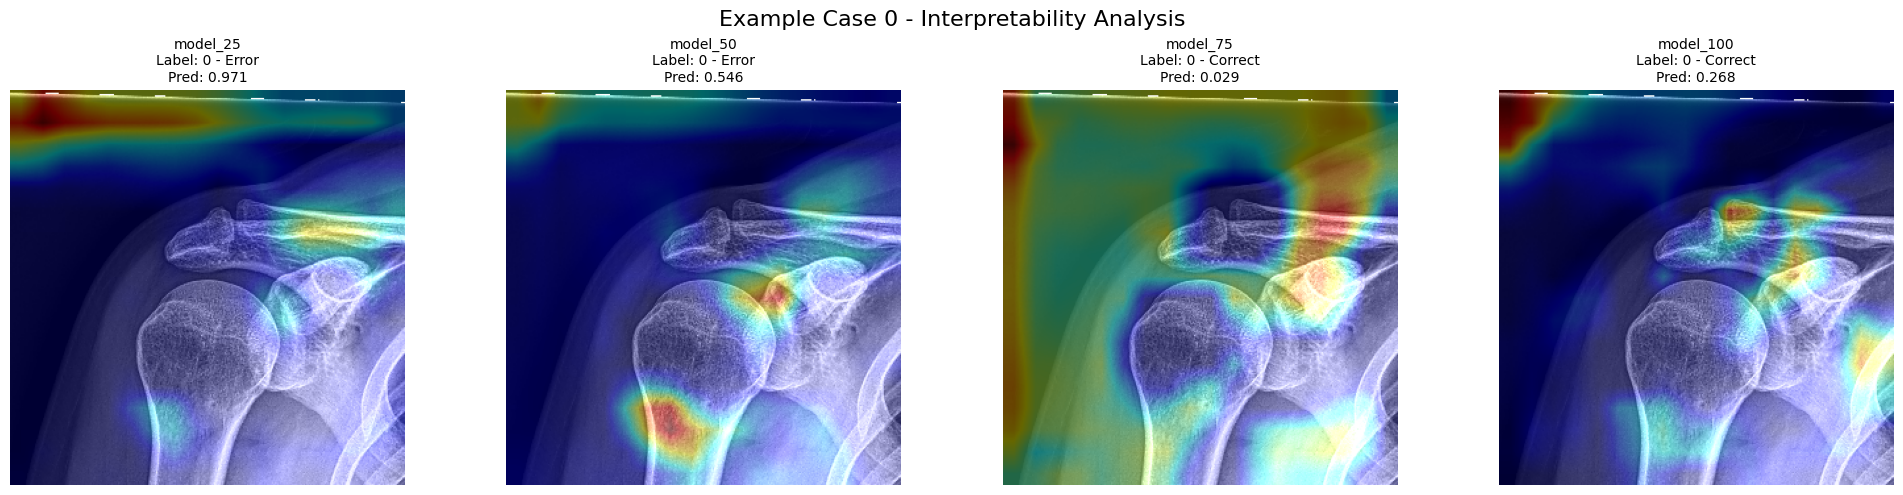

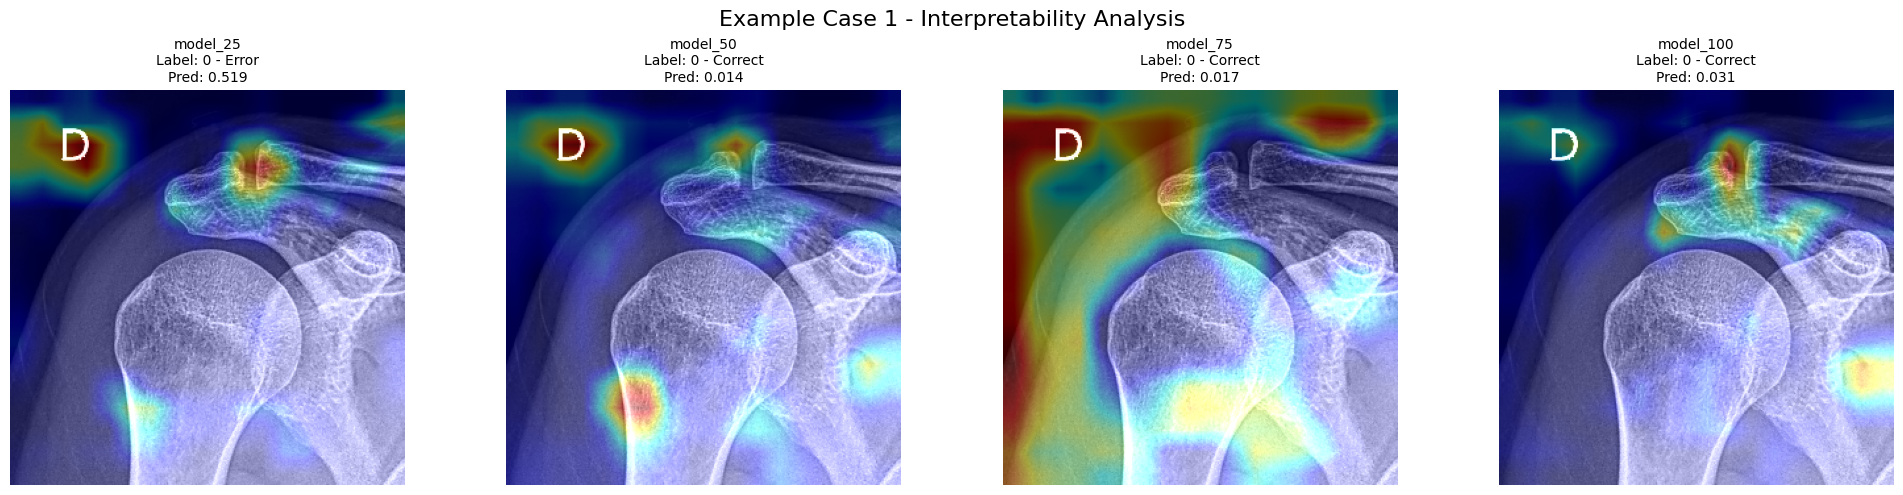

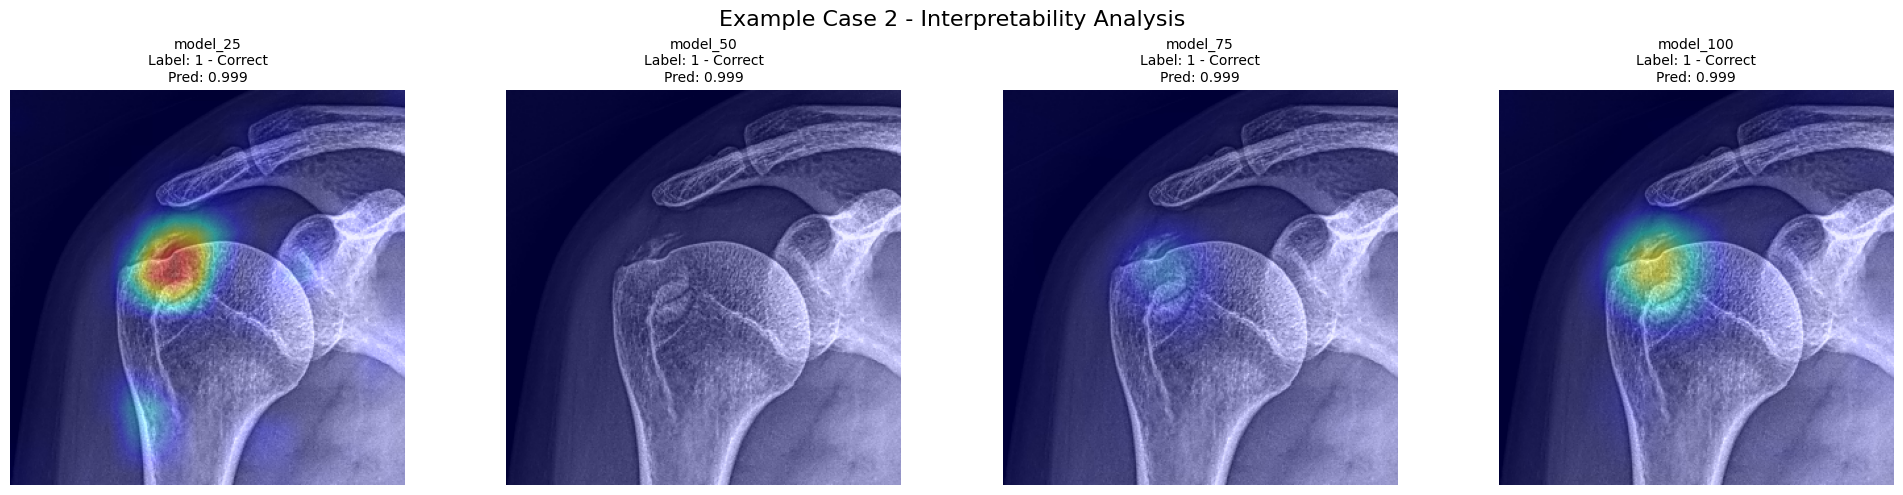

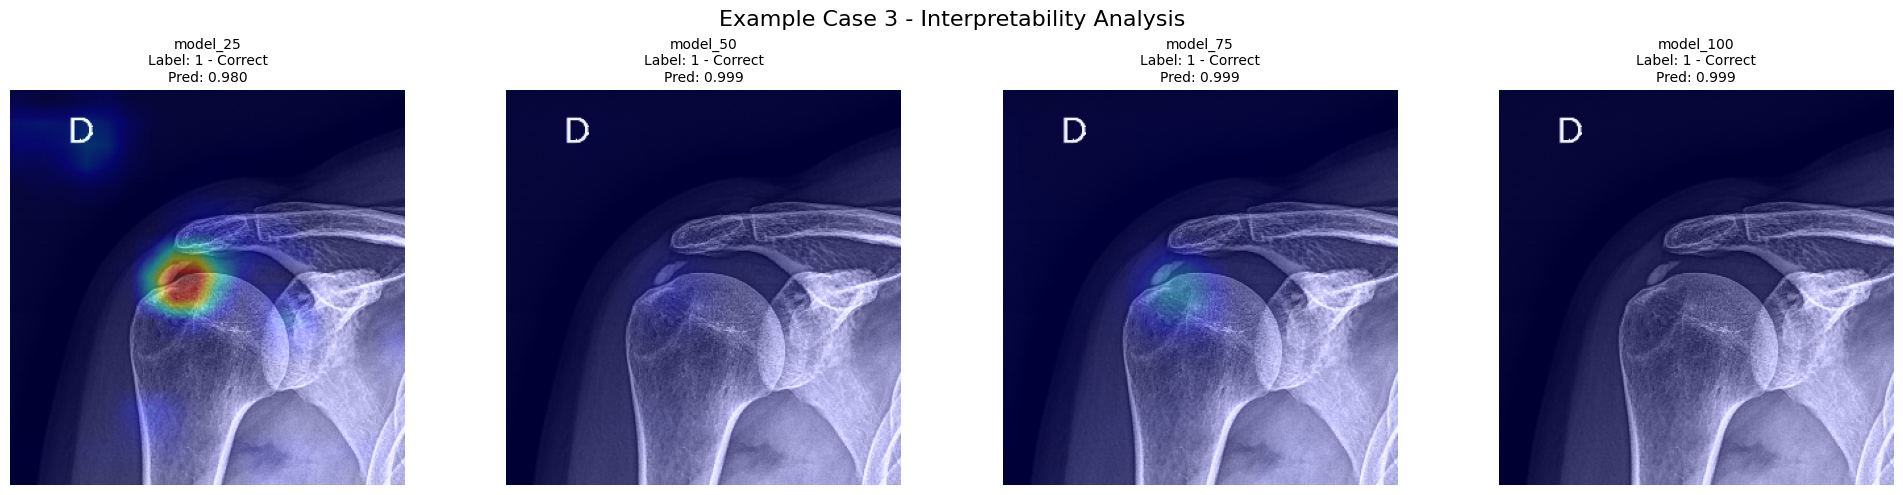

In [22]:
# === Function to plot Grad-CAM heatmaps by image (row-wise) ===

def plot_heatmaps_by_row(heatmaps_dict, y_true, y_pred_dict, model_names=None, max_images=4):
    """
    Plot Grad-CAM heatmaps for a subset of images, displaying one column per model.

    Parameters
    ----------
    heatmaps_dict : dict
        Dictionary mapping model name -> list of heatmap images (one per input image).
    y_true : array-like
        Ground-truth labels (0 or 1), one per image.
    y_pred_dict : dict
        Dictionary mapping model name -> list of predicted probabilities (float in [0, 1]).
    model_names : list of str, optional
        Ordered list of model names to display. If None, all keys in heatmaps_dict are used.
    max_images : int, optional
        Maximum number of examples to display. Default is 4.
    """
    import matplotlib.pyplot as plt

    model_names = model_names or list(heatmaps_dict.keys())
    n_models = len(model_names)
    
    # Limit the number of images to the specified maximum
    n_images = min(len(y_true), max_images)

    for i in range(n_images):
        fig, axs = plt.subplots(1, n_models, figsize=(n_models * 5, 5))
        fig.suptitle(f"Example Case {i} - Interpretability Analysis", fontsize=16)

        for j, model_name in enumerate(model_names):
            heatmap = heatmaps_dict[model_name][i]
            # Probabilities capped at 0.999 for visualization consistency
            pred_prob = min(y_pred_dict[model_name][i], 0.999)
            true_label = y_true[i]
            
            # Prediction logic (Threshold 0.5)
            pred_label = 1 if pred_prob >= 0.5 else 0
            status = "Correct" if pred_label == true_label else "Error"

            ax = axs[j]
            ax.imshow(heatmap)
            ax.axis("off")
            ax.set_title(
                f"{model_name}\n"
                f"Label: {true_label} - {status}\n"
                f"Pred: {pred_prob:.3f}",
                fontsize=10
            )

        plt.tight_layout()
        plt.subplots_adjust(top=0.82)
        plt.show()


# === Plot first 4 representative examples for Experiment 4 models ===
plot_heatmaps_by_row(
    heatmaps_dict=heatmaps_dict,
    y_true=y_all,
    y_pred_dict=y_pred_dict,
    model_names=[
        "model_25",
        "model_50",
        "model_75",
        "model_100",
    ],
    max_images=4  # Limits the output to the first 4 cases
)

### **7. Summary and Conclusions**

The results demonstrate a clear divergence between internal performance scaling and external generalization. While internal metrics improve consistently up to the full dataset (M100), external diagnostic performance reaches a functional plateau at the 75% training volume threshold (M75). Quantitatively, the external AUC improved significantly from the M25 model (0.800) to M75 (0.923), yet increasing the training volume to 100% yielded no statistically significant gain ($p = 0.496$). This indicates that the model reaches its maximum generalization capability well before utilizing the entire dataset.

This performance plateau suggests a phase of institutional over-optimization or shortcut learning. Beyond the 75% threshold, the model appears to prioritize site-specific technical signatures—such as detector-specific noise or workstation-dependent artifacts—rather than universal pathological markers. While these features reinforce on-domain accuracy within the training distribution, they fail to translate to external cohorts, effectively hindering the model’s ability to generalize to novel clinical environments.

Explainability analysis through Grad-CAM heatmaps visually corroborates these quantitative findings. Spatial precision and anatomical focus refine drastically as the training volume increases to M75, achieving precise superposition over calcific deposits. However, the transition from M75 to M100 provides no incremental interpretive gain or qualitative refinement in external attention maps. Collectively, these findings confirm that a critical data mass is sufficient for robust model development, whereas indiscriminate data accumulation from the same source fails to enhance either diagnostic reliability or model transparency.
